In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU') ###

import hmc_1hl as hmc

In [8]:
d = 150
alpha = 5
gamma = 1
Delta = 0.1
vlaw = 'ones'
k = int(gamma * d)

sig = lambda x: tf.nn.relu(x)

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 4000,
}

ntest = 10000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)

In [9]:
W0, v, X, Y = hmc.data_generate(d, alpha, gamma, sig, Delta, vlaw)
W1s = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=True)
W2s = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=True)

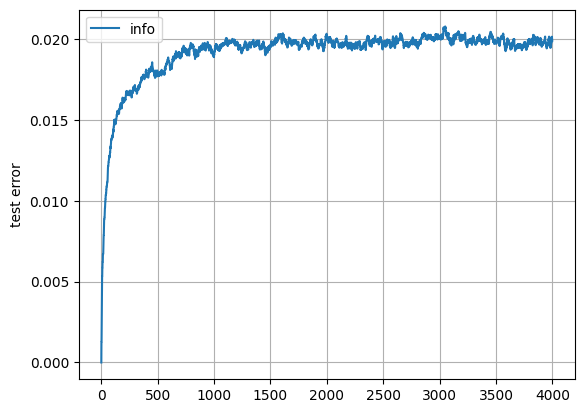

In [10]:
test_info = hmc.test_error(W1s, W0, v, sig, Xtest)
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
plt.grid()
plt.show()

In [13]:
e12 = np.array([hmc.lmda_err(W1s[i], W2s[i], v, sig, Xtest) for i in range(1, W1s.shape[0])])
e01 = np.array([hmc.lmda_err(W1s[i], W0, v, sig, Xtest) for i in range(1, W1s.shape[0])])
e02 = np.array([hmc.lmda_err(W2s[i], W0, v, sig, Xtest) for i in range(1, W1s.shape[0])])

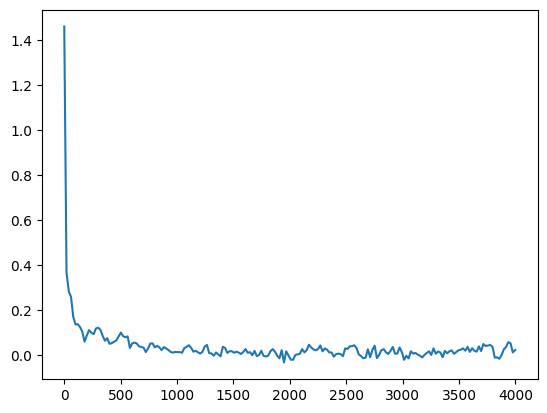

In [14]:
dev_info = e12/e01-1
idx = np.linspace(0, len(dev_info) - 1, 200, dtype=int)
plt.plot(idx, dev_info[idx])

In [16]:
np.savetxt('dev_info.csv', dev_info, delimiter=',')

In [21]:
# np.savetxt('dev_info.csv', dev_info, delimiter=',')